In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
!git clone https://github.com/CosmoIknosLab/NuLite /content/NuLite
os.chdir('/content/NuLite')
!pip install timm albumentations scikit-image torchinfo wandb pandas scipy numba natsort opencv-python tabulate torchmetrics --quiet

Cloning into '/content/NuLite'...
remote: Enumerating objects: 278, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 278 (delta 10), reused 14 (delta 4), pack-reused 245 (from 1)
Receiving objects: 100% (278/278), 102.27 MiB | 29.93 MiB/s, done.
Resolving deltas: 100% (58/58), done.
Updating files: 100% (221/221), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 55.2 MB/s eta 0:00:00


In [3]:
import glob
files = glob.glob('/content/drive/MyDrive/MoNuSegTestData/**/*', recursive=True)
for f in files[:20]:
    print(f)
print(f"Total: {len(files)}")

/content/drive/MyDrive/MoNuSegTestData/TCGA-69-7764-01A-01-TS1.tif
/content/drive/MyDrive/MoNuSegTestData/TCGA-FG-A4MU-01B-01-TS1.tif
/content/drive/MyDrive/MoNuSegTestData/TCGA-AO-A0J2-01A-01-BSA.tif
/content/drive/MyDrive/MoNuSegTestData/TCGA-AO-A0J2-01A-01-BSA.xml
/content/drive/MyDrive/MoNuSegTestData/TCGA-44-2665-01B-06-BS6.xml
/content/drive/MyDrive/MoNuSegTestData/TCGA-44-2665-01B-06-BS6.tif
/content/drive/MyDrive/MoNuSegTestData/TCGA-EJ-A46H-01A-03-TSC.tif
/content/drive/MyDrive/MoNuSegTestData/TCGA-A6-6782-01A-01-BS1.xml
/content/drive/MyDrive/MoNuSegTestData/TCGA-CU-A0YN-01A-02-BSB.xml
/content/drive/MyDrive/MoNuSegTestData/TCGA-EJ-A46H-01A-03-TSC.xml
/content/drive/MyDrive/MoNuSegTestData/TCGA-AC-A2FO-01A-01-TS1.tif
/content/drive/MyDrive/MoNuSegTestData/TCGA-AC-A2FO-01A-01-TS1.xml
/content/drive/MyDrive/MoNuSegTestData/TCGA-2Z-A9J9-01A-01-TS1.tif
/content/drive/MyDrive/MoNuSegTestData/TCGA-FG-A4MU-01B-01-TS1.xml
/content/drive/MyDrive/MoNuSegTestData/TCGA-2Z-A9J9-01A-01-TS1

**Preprocessing**

In [5]:
import os
import numpy as np
from PIL import Image
import xml.etree.ElementTree as ET
from skimage.draw import polygon
import glob

src = '/content/drive/MyDrive/MoNuSegTestData'
dst = '/content/drive/MyDrive/MoNuSeg_processed'
img_dir = f'{dst}/images'
msk_dir = f'{dst}/masks'
os.makedirs(img_dir, exist_ok=True)
os.makedirs(msk_dir, exist_ok=True)

PATCH_SIZE = 256

def parse_xml_mask(xml_path, img_h, img_w):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    mask = np.zeros((img_h, img_w), dtype=np.uint16)  # fixed
    inst_id = 1
    for region in root.iter('Region'):
        verts = region.findall('.//Vertex')
        if len(verts) < 3:
            continue
        xs = [float(v.attrib['X']) for v in verts]
        ys = [float(v.attrib['Y']) for v in verts]
        rr, cc = polygon(ys, xs, shape=(img_h, img_w))
        mask[rr, cc] = inst_id
        inst_id += 1
    return mask

tif_files = sorted(glob.glob(f'{src}/*.tif'))
patch_count = 0

for tif_path in tif_files:
    name = os.path.basename(tif_path).replace('.tif', '')
    xml_path = tif_path.replace('.tif', '.xml')
    if not os.path.exists(xml_path):
        print(f"No XML for {name}, skipping")
        continue

    img = np.array(Image.open(tif_path).convert('RGB'))
    h, w = img.shape[:2]
    mask = parse_xml_mask(xml_path, h, w)

    for y in range(0, h - PATCH_SIZE + 1, PATCH_SIZE):
        for x in range(0, w - PATCH_SIZE + 1, PATCH_SIZE):
            img_patch  = img[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
            mask_patch = mask[y:y+PATCH_SIZE, x:x+PATCH_SIZE]

            patch_name = f'{name}_{y}_{x}'
            Image.fromarray(img_patch).save(f'{img_dir}/{patch_name}.png')
            np.save(f'{msk_dir}/{patch_name}.npy', mask_patch)
            patch_count += 1

print(f"Done. Total patches: {patch_count}")
print(f"Saved to {dst}")

Done. Total patches: 126
Saved to /content/drive/MyDrive/MoNuSeg_processed


**inference**

In [1]:
import sys, os
sys.path.insert(0, '/content/NuLite')
os.chdir('/content/NuLite')

from google.colab import drive
drive.mount('/content/drive')

import torch
import numpy as np
from PIL import Image
import glob
from tqdm import tqdm

# Fix torch.load without recursion
import numpy._core.multiarray
torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])
_real_load = torch.load

def safe_load(f, **kwargs):
    kwargs['weights_only'] = False
    return _real_load(f, **kwargs)

from models.nulite import NuLite

checkpoint = safe_load(
    '/content/drive/MyDrive/NuLite_Exp1_outputs/checkpoints/model_best.pth',
    map_location='cpu'
)
model = NuLite(num_nuclei_classes=6, num_tissue_classes=19, vit_structure='fastvit_t8')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Model loaded.")

import albumentations as A
from albumentations.pytorch import ToTensorV2

transform = A.Compose([
    A.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),
    ToTensorV2()
])

img_files = sorted(glob.glob('/content/drive/MyDrive/MoNuSeg_processed/images/*.png'))
msk_files = sorted(glob.glob('/content/drive/MyDrive/MoNuSeg_processed/masks/*.npy'))

def dice_score(pred, gt):
    intersection = (pred * gt).sum()
    return (2. * intersection) / (pred.sum() + gt.sum() + 1e-8)

def jaccard_score(pred, gt):
    intersection = (pred * gt).sum()
    union = pred.sum() + gt.sum() - intersection
    return intersection / (union + 1e-8)

dice_scores = []
jacc_scores = []

with torch.no_grad():
    for img_path, msk_path in tqdm(zip(img_files, msk_files), total=len(img_files)):
        img = np.array(Image.open(img_path).convert('RGB'))
        mask_gt = np.load(msk_path)
        binary_gt = (mask_gt > 0).astype(np.float32)

        augmented = transform(image=img)
        tensor = augmented['image'].unsqueeze(0).float()

        out = model(tensor)

        np_pred = torch.softmax(out['nuclei_binary_map'], dim=1)[:, 1, :, :]
        binary_pred = (np_pred > 0.5).float().squeeze(0).numpy()

        d = dice_score(binary_pred, binary_gt)
        j = jaccard_score(binary_pred, binary_gt)

        dice_scores.append(float(d))
        jacc_scores.append(float(j))

print(f"\n=== MoNuSeg Generalization Results (Exp1, 20 epochs) ===")
print(f"Mean Dice:    {np.mean(dice_scores):.4f}")
print(f"Mean Jaccard: {np.mean(jacc_scores):.4f}")
print(f"Std Dice:     {np.std(dice_scores):.4f}")
print(f"Std Jaccard:  {np.std(jacc_scores):.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


model.safetensors:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

Model loaded.


100%|██████████| 126/126 [01:09<00:00,  1.82it/s]


=== MoNuSeg Generalization Results (Exp1, 20 epochs) ===
Mean Dice:    0.7473
Mean Jaccard: 0.6005
Std Dice:     0.0632
Std Jaccard:  0.0773


                 Dataset   Dice  Jaccard Std Dice Std Jacc
        PanNuke (Fold 2) 0.7331   0.6195        -        -
MoNuSeg (Generalization) 0.7473   0.6005   0.0632   0.0773


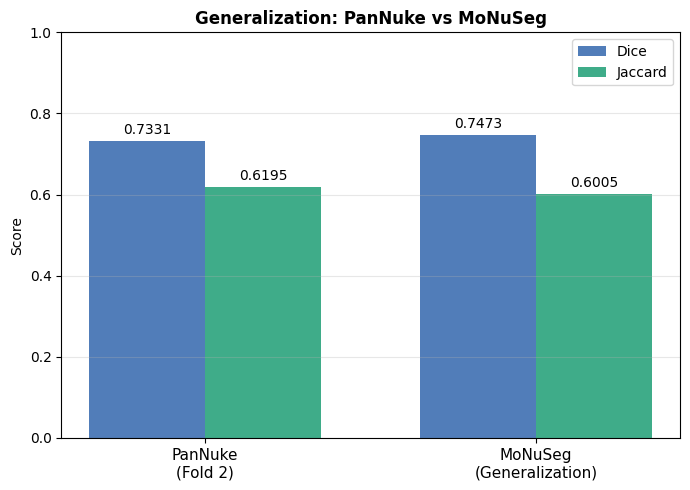

Saved.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

out = '/content/drive/MyDrive/MoNuSeg_processed'
os.makedirs(f'{out}/plots', exist_ok=True)

# ── Results summary table ───────────────────────────────────
results = {
    'Dataset':  ['PanNuke (Fold 2)', 'MoNuSeg (Generalization)'],
    'Dice':     [0.7331, 0.7473],
    'Jaccard':  [0.6195, 0.6005],
    'Std Dice': ['-', '0.0632'],
    'Std Jacc': ['-', '0.0773'],
}
df = pd.DataFrame(results)
df.to_csv(f'{out}/plots/generalization_results.csv', index=False)
print(df.to_string(index=False))

# ── Bar chart ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(2)
w = 0.35
datasets = ['PanNuke\n(Fold 2)', 'MoNuSeg\n(Generalization)']
dice_vals = [0.7331, 0.7473]
jacc_vals = [0.6195, 0.6005]

bars1 = ax.bar(x - w/2, dice_vals, w, label='Dice',    color='#3266ad', alpha=0.85)
bars2 = ax.bar(x + w/2, jacc_vals, w, label='Jaccard', color='#1D9E75', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('Generalization: PanNuke vs MoNuSeg', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{out}/plots/generalization_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")